# Safiri AI — Predicting Port Congestion and Shipment Delays Using AI

## I. Imports & Config

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap
import sys, os, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score
import xgboost as xgb

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from data.generate_synthetic_data import (
    generate_synthetic_data_1st_version,
    generate_synthetic_data_2nd_version
)

# ── Global config ──
COLS_TO_DROP   = ['delay_minutes', 'congestion_label', 'congestion_level', 'confidence_score']
DATASET_SIZES  = [500, 5_000, 50_000, 500_000]
VERSIONS       = [
    ('V1 - Linear / Simple',     generate_synthetic_data_1st_version),
    ('V2 - Non-Linear / Complex', generate_synthetic_data_2nd_version),
]
# Accumulates ROC-AUC for the scalability table
all_results = []

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

/Users/kelvinnguyen/Projects/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## II. Helper Functions

### 1. Data

In [2]:
# ── DATA ────────────────────────────────────────────────────
def generate_data(gen_func, size):
    """Generate a synthetic dataset of the given size."""
    return gen_func(num_records=size)


def prepare_features(df):
    """Drop targets, one-hot encode vessel_type, return X and y."""
    X = df.drop(columns=COLS_TO_DROP)
    X = pd.get_dummies(X, columns=['vessel_type'], drop_first=True).astype(float)
    y = df['congestion_label']
    return train_test_split(X, y, test_size=0.2, random_state=42)
  

### 2. EDA

In [3]:
def plot_eda_overview(df, version_name, size):
    """4-panel EDA grid: class balance, capacity scatter, wind scatter, heatmap."""
    fig = plt.figure(figsize=(20, 14))
    fig.suptitle(f'EDA Overview | {version_name} | {size:,} records',
                 fontsize=16, fontweight='bold', y=1.01)
    gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

    # Class balance
    ax1    = fig.add_subplot(gs[0, 0])
    counts = df['congestion_label'].value_counts().sort_index()
    bars   = ax1.bar(['Clear (0)', 'Congested (1)'], counts.values,
                      color=['#2ecc71', '#e74c3c'], edgecolor='white')
    for bar, v in zip(bars, counts.values):
        ax1.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + max(counts)*0.01,
                 f'{v:,}\n({v/size*100:.1f}%)', ha='center', va='bottom', fontsize=10)
    ax1.set_title('Target Class Balance', fontsize=13, fontweight='bold')
    ax1.set_ylabel('Number of Vessels')
    ax1.set_ylim(0, max(counts) * 1.18)

    # Capacity vs Delay
    ax2    = fig.add_subplot(gs[0, 1])
    sample = df.sample(min(2000, size), random_state=42)
    sc     = ax2.scatter(sample['port_capacity_utilization'], sample['delay_minutes'],
                          c=sample['congestion_label'], cmap='RdYlGn_r', alpha=0.4, s=15)
    ax2.axhline(y=240, color='red', linestyle='--', linewidth=1.4, label='Congestion (240 min)')
    ax2.set_title('Capacity vs Delay', fontsize=13, fontweight='bold')
    ax2.set_xlabel('Port Capacity Utilization')
    ax2.set_ylabel('Delay (minutes)')
    ax2.legend(fontsize=9)
    plt.colorbar(sc, ax=ax2, label='Congested?')

    # Wind vs Delay
    ax3 = fig.add_subplot(gs[1, 0])
    sc2 = ax3.scatter(sample['wind_speed_knots'], sample['delay_minutes'],
                      c=sample['congestion_label'], cmap='RdYlGn_r', alpha=0.4, s=15)
    ax3.axvline(x=35, color='orange', linestyle='--', linewidth=1.4, label='Halt (35 knots)')
    ax3.axhline(y=240, color='red',    linestyle='--', linewidth=1.4, label='Congestion (240 min)')
    ax3.set_title('Wind Speed vs Delay', fontsize=13, fontweight='bold')
    ax3.set_xlabel('Wind Speed (knots)')
    ax3.set_ylabel('Delay (minutes)')
    ax3.legend(fontsize=9)
    plt.colorbar(sc2, ax=ax3, label='Congested?')

    # Correlation heatmap
    ax4  = fig.add_subplot(gs[1, 1])
    corr = df.drop(columns=['congestion_level']).corr()
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, ax=ax4, annot_kws={'size': 7}, linewidths=0.4)
    ax4.set_title('Correlation Heatmap', fontsize=13, fontweight='bold')
    ax4.tick_params(axis='x', rotation=45, labelsize=8)
    ax4.tick_params(axis='y', rotation=0,  labelsize=8)
    plt.show()


def plot_physics_proof(df, version_name):
    """3-panel chart proving why  models are needed."""
    sns.set_theme(style='whitegrid', context='talk')
    fig, axes = plt.subplots(1, 3, figsize=(24, 7))
    fig.suptitle(f'Proving the Need for XGBoost: Port Physics | {version_name}',
                 fontsize=18, fontweight='bold', y=1.05)

    # Panel 1 — Hockey Stick
    sns.regplot(data=df, x='port_capacity_utilization', y='delay_minutes',
                order=3,
                scatter_kws={'alpha': 0.5, 'color': '#3498db'},
                line_kws={'color': '#e74c3c', 'linewidth': 3},
                ax=axes[0])
    axes[0].set_title('1. The "Hockey Stick" Curve\n(Exponential Capacity)', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Port Capacity Utilization (0.0 to 1.0)', fontsize=12)
    axes[0].set_ylabel('Total Delay (Minutes)', fontsize=12)
    axes[0].axvline(x=0.85, color='black', linestyle='--', alpha=0.7)
    axes[0].text(0.86, df['delay_minutes'].max() * 0.85,
                 'Critical Gridlock\n(>85% Capacity)', color='black', fontweight='bold', fontsize=10)

    # Panel 2 — Hard Stop
    sns.scatterplot(data=df, x='wind_speed_knots', y='delay_minutes',
                    hue='congestion_label',
                    palette={0: '#2ecc71', 1: '#e74c3c'}, alpha=0.7, ax=axes[1])
    axes[1].axvline(x=35, color='black', linestyle='--', linewidth=2)
    axes[1].set_title('2. The "Hard Stop" Threshold\n(Crane Operations Halt)', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Wind Speed (Knots)', fontsize=12)
    axes[1].set_ylabel('Total Delay (Minutes)', fontsize=12)
    axes[1].get_legend().remove()
    axes[1].text(35.5, df['delay_minutes'].min(),
                 'Cranes Locked\n(>35 Knots)', color='black', fontweight='bold', fontsize=10)

    # Panel 3 — Midnight Gridlock interaction
    NIGHT_LABEL      = 'Night (22:00-04:00)'
    DAY_LABEL        = 'Daytime'
    HIGH_CAP_LABEL   = 'High Capacity (>80%)'
    NORMAL_CAP_LABEL = 'Normal Capacity'
    plot_df = df.copy()
    plot_df['Arrival Window'] = np.where(
        (plot_df['arrival_hour'] >= 22) | (plot_df['arrival_hour'] <= 4),
        NIGHT_LABEL, DAY_LABEL)
    plot_df['Yard Status'] = np.where(
        plot_df['port_capacity_utilization'] > 0.80,
        HIGH_CAP_LABEL, NORMAL_CAP_LABEL)
    sns.barplot(data=plot_df, x='Arrival Window', y='delay_minutes', hue='Yard Status',
                palette={NORMAL_CAP_LABEL: '#95a5a6', HIGH_CAP_LABEL: '#e67e22'},
                errorbar=None, ax=axes[2])
    axes[2].set_title('3. The "Midnight Gridlock"\n(Variable Interaction)', fontsize=14, fontweight='bold')
    axes[2].set_xlabel('Arrival Time Window', fontsize=12)
    axes[2].set_ylabel('Average Delay (Minutes)', fontsize=12)
    plt.tight_layout()
    plt.show()
    # Reset theme after the 'talk' context
    sns.set_theme(style='whitegrid', palette='muted')

### 3. Models

In [4]:
def train_models(X_train, y_train):
    """Instantiate and train the 3 models. Returns a dict of trained models."""
    models = {
        'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
        'Random Forest':       RandomForestClassifier(n_estimators=100, max_depth=5,
                                                      n_jobs=-1, random_state=42),
        'XGBoost':             xgb.XGBClassifier(n_estimators=200, learning_rate=0.05,
                                                  max_depth=5, objective='binary:logistic',
                                                  n_jobs=-1, random_state=42),
    }
    for mobj in models.values():
        mobj.fit(X_train, y_train)
    return models


In [5]:
def evaluate_models(trained_models, X_test, y_test):
    """Compute metrics for each model. Returns a list of metric dicts."""
    rows = []
    for mname, mobj in trained_models.items():
        preds  = mobj.predict(X_test)
        probas = mobj.predict_proba(X_test)[:, 1]
        rows.append({
            'Model':     mname,
            'Accuracy':  f"{accuracy_score(y_test, preds)*100:.2f}%",
            'ROC-AUC':   f"{roc_auc_score(y_test, probas)*100:.2f}%",
            'Precision': f"{precision_score(y_test, preds, zero_division=0)*100:.2f}%",
            'Recall':    f"{recall_score(y_test, preds, zero_division=0)*100:.2f}%",
        })
    return rows

In [6]:
def print_metrics_table(metric_rows, version_name, size):
    """Print the metrics table to stdout (used for all dataset sizes)."""
    print(f'\n  Model Metrics | {version_name} | {size:,} records')
    print('  ' + '-' * 75)
    print(pd.DataFrame(metric_rows).to_string(index=False))


In [7]:
def plot_model_comparison(metric_rows, version_name, size):
    """Horizontal bar chart of ROC-AUC (only for primary 500-record analysis)."""
    fig, ax = plt.subplots(figsize=(10, 4))
    names  = [r['Model'] for r in metric_rows]
    aucs   = [float(r['ROC-AUC'].strip('%')) for r in metric_rows]
    colors = ['#3498db', '#9b59b6', '#e67e22']
    bars   = ax.barh(names, aucs, color=colors, edgecolor='white')
    for bar, v in zip(bars, aucs):
        ax.text(v - 0.5, bar.get_y() + bar.get_height()/2,
                f'{v:.2f}%', va='center', ha='right',
                color='white', fontweight='bold', fontsize=11)
    ax.set_xlim(50, 101)
    ax.set_xlabel('ROC-AUC (%)')
    ax.set_title(f'Model ROC-AUC Comparison | {version_name} | {size:,} records',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

### 4. SHAP

In [8]:
def plot_shap_global(xgb_model, X_shap, version_name, size):
    """SHAP beeswarm summary: global feature importance."""
    explainer = shap.TreeExplainer(xgb_model)
    shap_vals = explainer.shap_values(X_shap)
    plt.figure(figsize=(10, 7))
    plt.title(f'SHAP Global Feature Importance | {version_name} | {size:,} records',
              fontsize=13, fontweight='bold')
    shap.summary_plot(shap_vals, X_shap, show=False)
    plt.tight_layout()
    plt.show()


In [9]:
def plot_shap_waterfall(xgb_model, X_train, X_test, y_test, version_name, size):
    """SHAP waterfall for Vessel #0: local explanation."""
    explainer2 = shap.Explainer(xgb_model, X_train)
    shap_vals2 = explainer2(X_test.head(min(len(X_test), 300)))
    pred_prob  = xgb_model.predict_proba(X_test.iloc[[0]])[0][1]
    truth      = 'CONGESTED' if y_test.iloc[0] == 1 else 'CLEAR'
    print(f'\n  Vessel #0: Confidence = {pred_prob*100:.2f}% | Actual = {truth}')
    plt.figure(figsize=(10, 6))
    plt.title(f'SHAP Waterfall: Why Vessel #0 was Flagged (Conf: {pred_prob*100:.1f}%) | {version_name}',
              fontsize=11, fontweight='bold')
    shap.plots.waterfall(shap_vals2[0], show=False)
    plt.tight_layout()
    plt.show()

## III. Run Primary Analysis

### 1. V1 - Linear Baseline

In [10]:
# 1. Generate & Prepare
version_name, gen_func = VERSIONS[0] # V1
df_v1 = generate_data(gen_func, 500)
X_train_v1, X_test_v1, y_train_v1, y_test_v1 = prepare_features(df_v1)


Generated 500 records → /Users/kelvinnguyen/Projects/safiri-port-congestion-ai/data/synthetic_port_data_v1_500.csv

Binary Label Distribution (congestion_label):
   0 — No/Low congestion (≤240 min) : 169 (33.8%)
   1 — Congestion        (>240 min) : 331 (66.2%)

3-Class Distribution (congestion_level):
   0 — No Congestion   (≤120 min) : 8
   1 — Moderate        (≤360 min) : 365
   2 — High Congestion (>360 min) : 127

Delay Statistics (delay_minutes):
count    500.0
mean     265.1
std       57.8
min       96.1
25%      227.6
50%      263.9
75%      301.4
max      454.1


In [11]:
df_v1.head()

,arrival_vessels_24h,port_capacity_utilization,visibility_km,wind_speed_knots,queue_length,arrival_hour,vessel_type,is_monsoon_season,day_of_week,delay_minutes,congestion_label,congestion_level,confidence_score
0,43,0.3861,16.21,22.49,11,5,0,0,2,290.48,1,1,0.6492
1,33,0.6574,19.60,8.90,12,17,2,0,1,272.97,1,1,0.6321
2,19,0.4276,16.96,21.20,5,5,2,1,6,305.97,1,2,0.6643
3,47,0.6794,17.47,28.72,10,18,1,0,3,282.86,1,1,0.6418
4,12,0.3895,8.75,28.18,4,11,1,1,3,218.70,0,1,0.6208


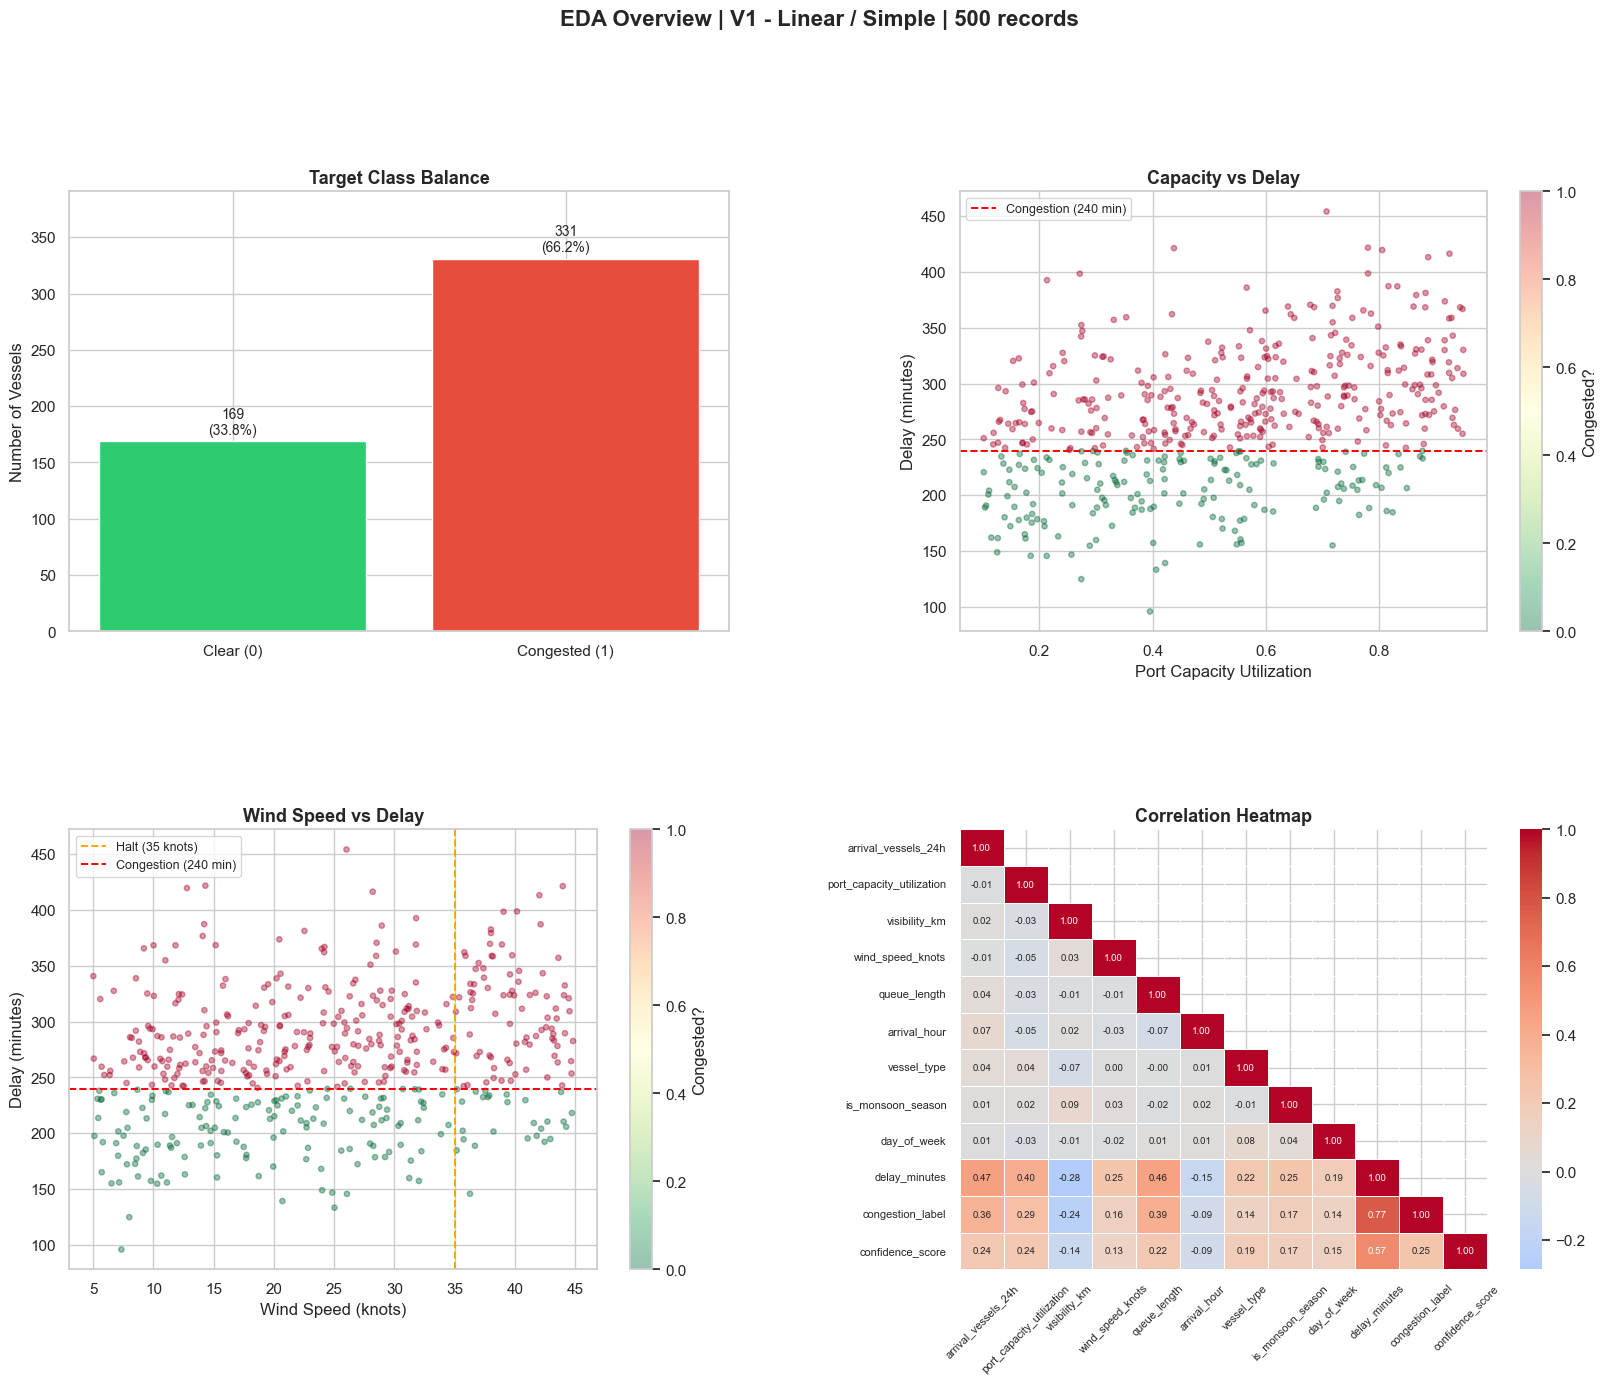

In [12]:
plot_eda_overview(df_v1, version_name, 500)

**Observation:**

Based on the EDA Overview for the V1 (Linear/Simple) dataset, here are the key observations:

1. Target Imbalance: There are roughly twice as many 'Congested' cases (66.2%) as 'Clear' cases (33.8%), making the dataset somewhat imbalanced toward congestion.
2. Linear Relationships (Scatter Plots):
    *   Capacity vs. Delay & Wind Speed vs. Delay: Both plots show a clear, predictable upward trend. As capacity or wind increases, delay rises steadily in a straight line, confirming the simple, additive nature of the V1 rules.
    *   No "Hard-Stop" Effects: In the Wind Speed plot, crossing the 35-knot threshold does not trigger any sudden, massive spike in delays; the data just continues its gradual upward slope.
3. Strong Independent Drivers (Heatmap): The correlations show that basic features independently drive delays. The strongest linear predictors are `arrival_vessels_24h` (0.47), `queue_length` (0.46), and `port_capacity_utilization` (0.40), verifying that the V1 dataset lacks complex interactions.

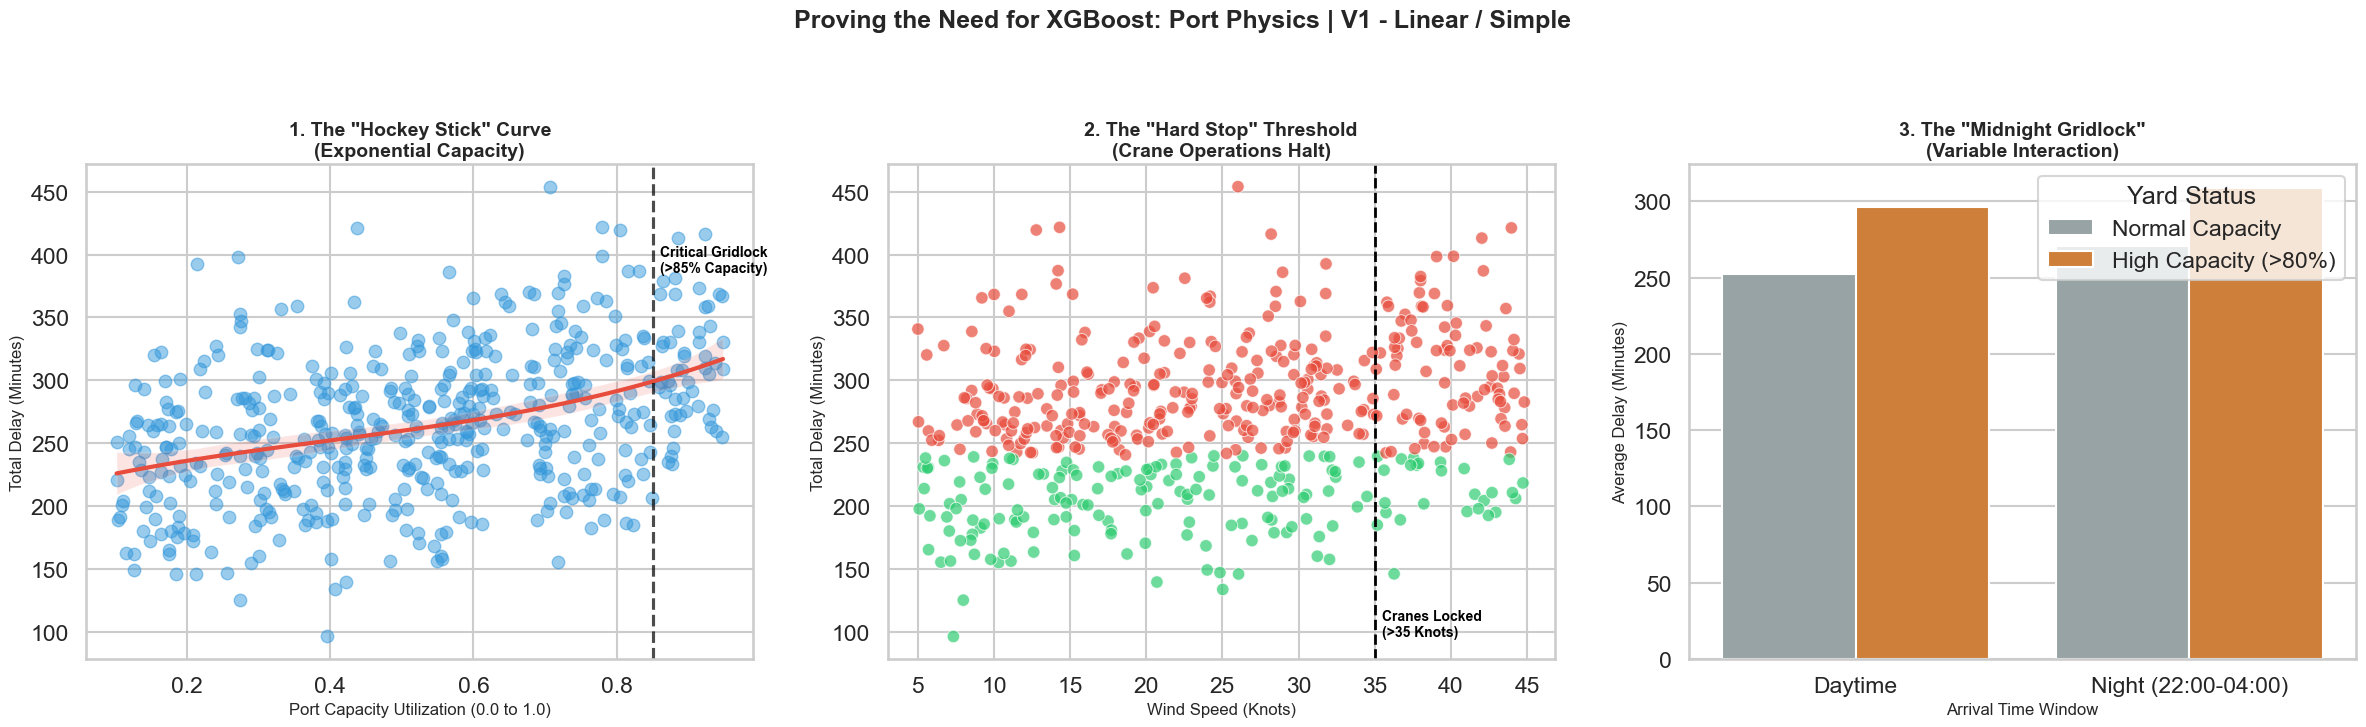

In [13]:
plot_physics_proof(df_v1, version_name)

**Observation:**

- No "Hockey Stick" (Panel 1): The regression line is perfectly straight. Delays grow linearly with capacity, completely failing to capture the real-world exponential queueing ($M/M/1$) explosion that happens past 80% saturation.

- No "Hard Stops" (Panel 2): Crossing the 35-knot wind threshold causes no sudden spike or cluster of extreme delays. The data ignores the physical reality that cranes are completely shut down at this speed.

- No Variables Interacting (Panel 3): The height difference between the grey and orange bars is exactly the same during the day as it is at night. The model treats "nighttime" and "high capacity" as simple, independent additions—missing the severe compounding "midnight gridlock" multiplier effect of Cat Lai.


  Model Metrics | V1 - Linear / Simple | 500 records
  ---------------------------------------------------------------------------
              Model Accuracy ROC-AUC Precision Recall
Logistic Regression   90.00%  95.62%    90.91% 93.75%
      Random Forest   80.00%  92.66%    78.21% 95.31%
            XGBoost   83.00%  93.79%    84.06% 90.62%


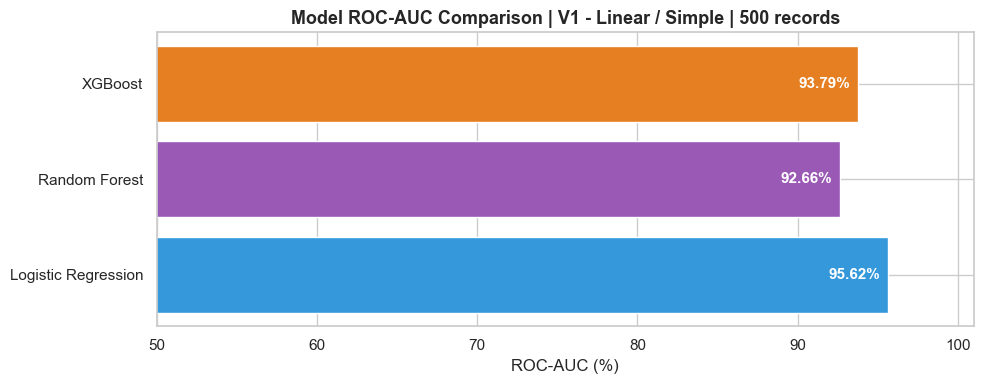

In [14]:
# 3. Train & Metrics
trained_v1 = train_models(X_train_v1, y_train_v1)
metrics_v1 = evaluate_models(trained_v1, X_test_v1, y_test_v1)
print_metrics_table(metrics_v1, version_name, 500)
plot_model_comparison(metrics_v1, version_name, 500)

# Save results for final table
for row in metrics_v1:
    all_results.append({'Version': version_name, 'Records': '500', 'Model': row['Model'], 'ROC-AUC': row['ROC-AUC']})


**Obsevation:**

- The simplest model win. Logistic Regression (95.62%) is actively beating the powerful XGBoost (93.79%) and Random Forest (92.66%) models.
- Reason: Because V1 data was generated using strict, simple, additive straight lines, it perfectly matches the mathematical design of Logistic Regression. Conversely, XGBoost and Random Forest is tree-based models built to hunt for complex "if/then" thresholds and feature interactions. On a small (500 records), perfect linear dataset, these advanced models are essentially "overthinking" the problem and capturing slightly more noise than signal.

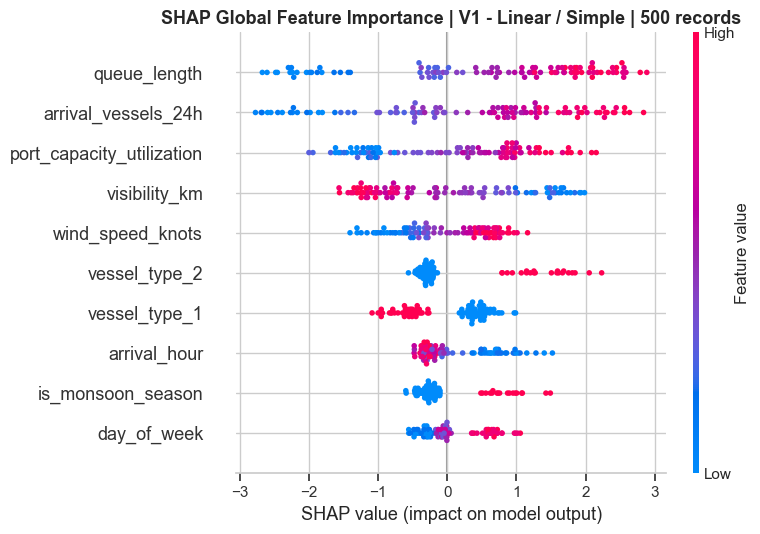

In [15]:
# 4. SHAP
X_shap_v1 = X_test_v1.head(500)
plot_shap_global(trained_v1['XGBoost'], X_shap_v1, version_name, 500)


##### **Observation**:

1. SHAP Global Feature Importance:
    - queue_length: 
        - Pink dots (high queue) are spread far to the right -> high queue, meaning they are strongly pushing toward Congested
        - Blue dots (low queue) are spead far to the left -> low queue, meaning they are strongly pushing toward Clear
        - Conclusion: Long queues meaning port gridlock
    - wind_speed_knots:
        - Pink dots (high wind) cluster to the far right with SHAP up to +3 -> wind is dangerous (knots over 35) then the model screams "Congested"
        - Blue dots (low wind) sit near 0 or slightly left -> normal wind has almost no effect
    - port_capacity_utilization:
        - Blue dots are pushed hard to the left -> capacity is low, model says clear
        - Pink dots are push right -> when capacity is high, model says Congested
    - vessel_type (1 and 2):
        - Blue dots cluster LEFT, pink dots cluster RIGHT (in type 1) → vessel type clearly separates congestion risk
        - Different vessel types (tankers vs. bulk carriers) have different unloading times
    - arrival_hour:
        - Mixed colors near 0 → The model is uncertain about arrival hour alone
    - is_monsoon_season:
        - Almost all dots cluster near 0 → The model learned monsoon alone doesn't reliably predict congestion; it is a background modifier



  Vessel #0: Confidence = 0.52% | Actual = CLEAR


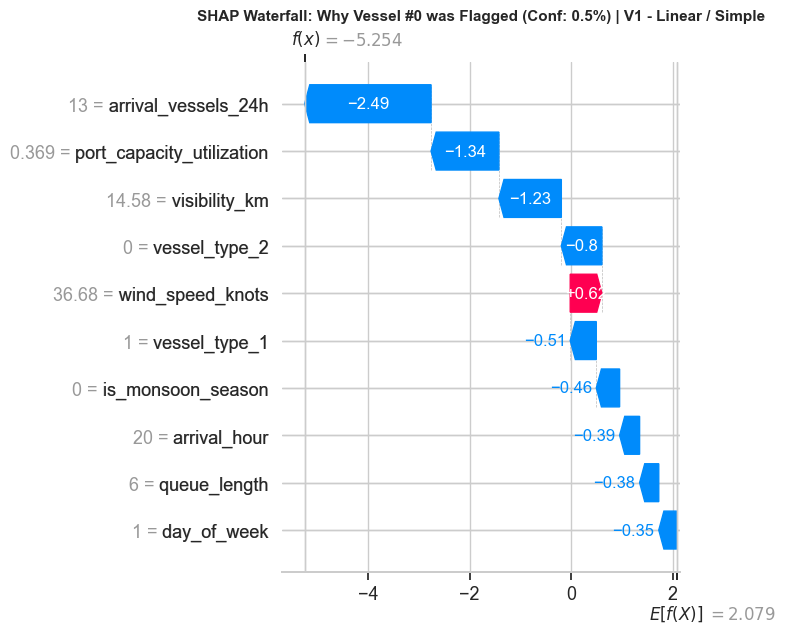

In [16]:
plot_shap_waterfall(trained_v1['XGBoost'], X_train_v1, X_test_v1, y_test_v1, version_name, 500)

##### **Observation**:

2. SHAP Waterfall:
    THis is a story related to vessel #0 on test set of dataset v1.

    - The Starting Line: E[f(X)] = 2.079 (Bottom Right)
        -> This is the model's "average guess." Before the AI looks at any specific data about Vessel #0, it starts at this baseline number. Think of it as the default state of the port.
    - The Final Answer: f(x) = -5.254 (Top Center)
        -> This is the final raw math score for Vessel #0, meaning that this negative number like -5.254 translates to a very low percentage. This is where 0.5% Confestion Confidence comes from. The model is almost certain this ship is Clear.
    - Operation:
        - We can sum up figues from all the related feature we have of vessel #0 with E[f(X)], we can get the final answer then.
    - The features:
        - Similar to SHAP feature Importance, blue bar meaning drove the risk (closer to Clear), vice versa with pink bar (closer to Congested)
        - For example, arrival_vessels_24h = 13 is a massive blue bar, this port only had 13 ships arrive today. That is very light traffic. The XGBoost saw this and massively reduced the congestion risk. Conversely, wind_speed_knots = 36.68 (Small Red Bar, +0.62) meaning the wind is blowing hard. The XGBoost model added a little bit of risk.

### 2. V2 - Complex Physics

Generated 500 records → /Users/kelvinnguyen/Projects/safiri-port-congestion-ai/data/synthetic_port_data_v2_500.csv

Binary Label Distribution (congestion_label):
   0 — No/Low congestion (≤240 min) : 204 (40.8%)
   1 — Congestion        (>240 min) : 296 (59.2%)

3-Class Distribution (congestion_level):
   0 — No Congestion   (≤120 min) : 74
   1 — Moderate        (≤360 min) : 214
   2 — High Congestion (>360 min) : 212

Delay Statistics (delay_minutes):
count    500.0
mean     288.5
std      128.7
min       44.0
25%      184.8
50%      273.0
75%      372.1
max      678.8


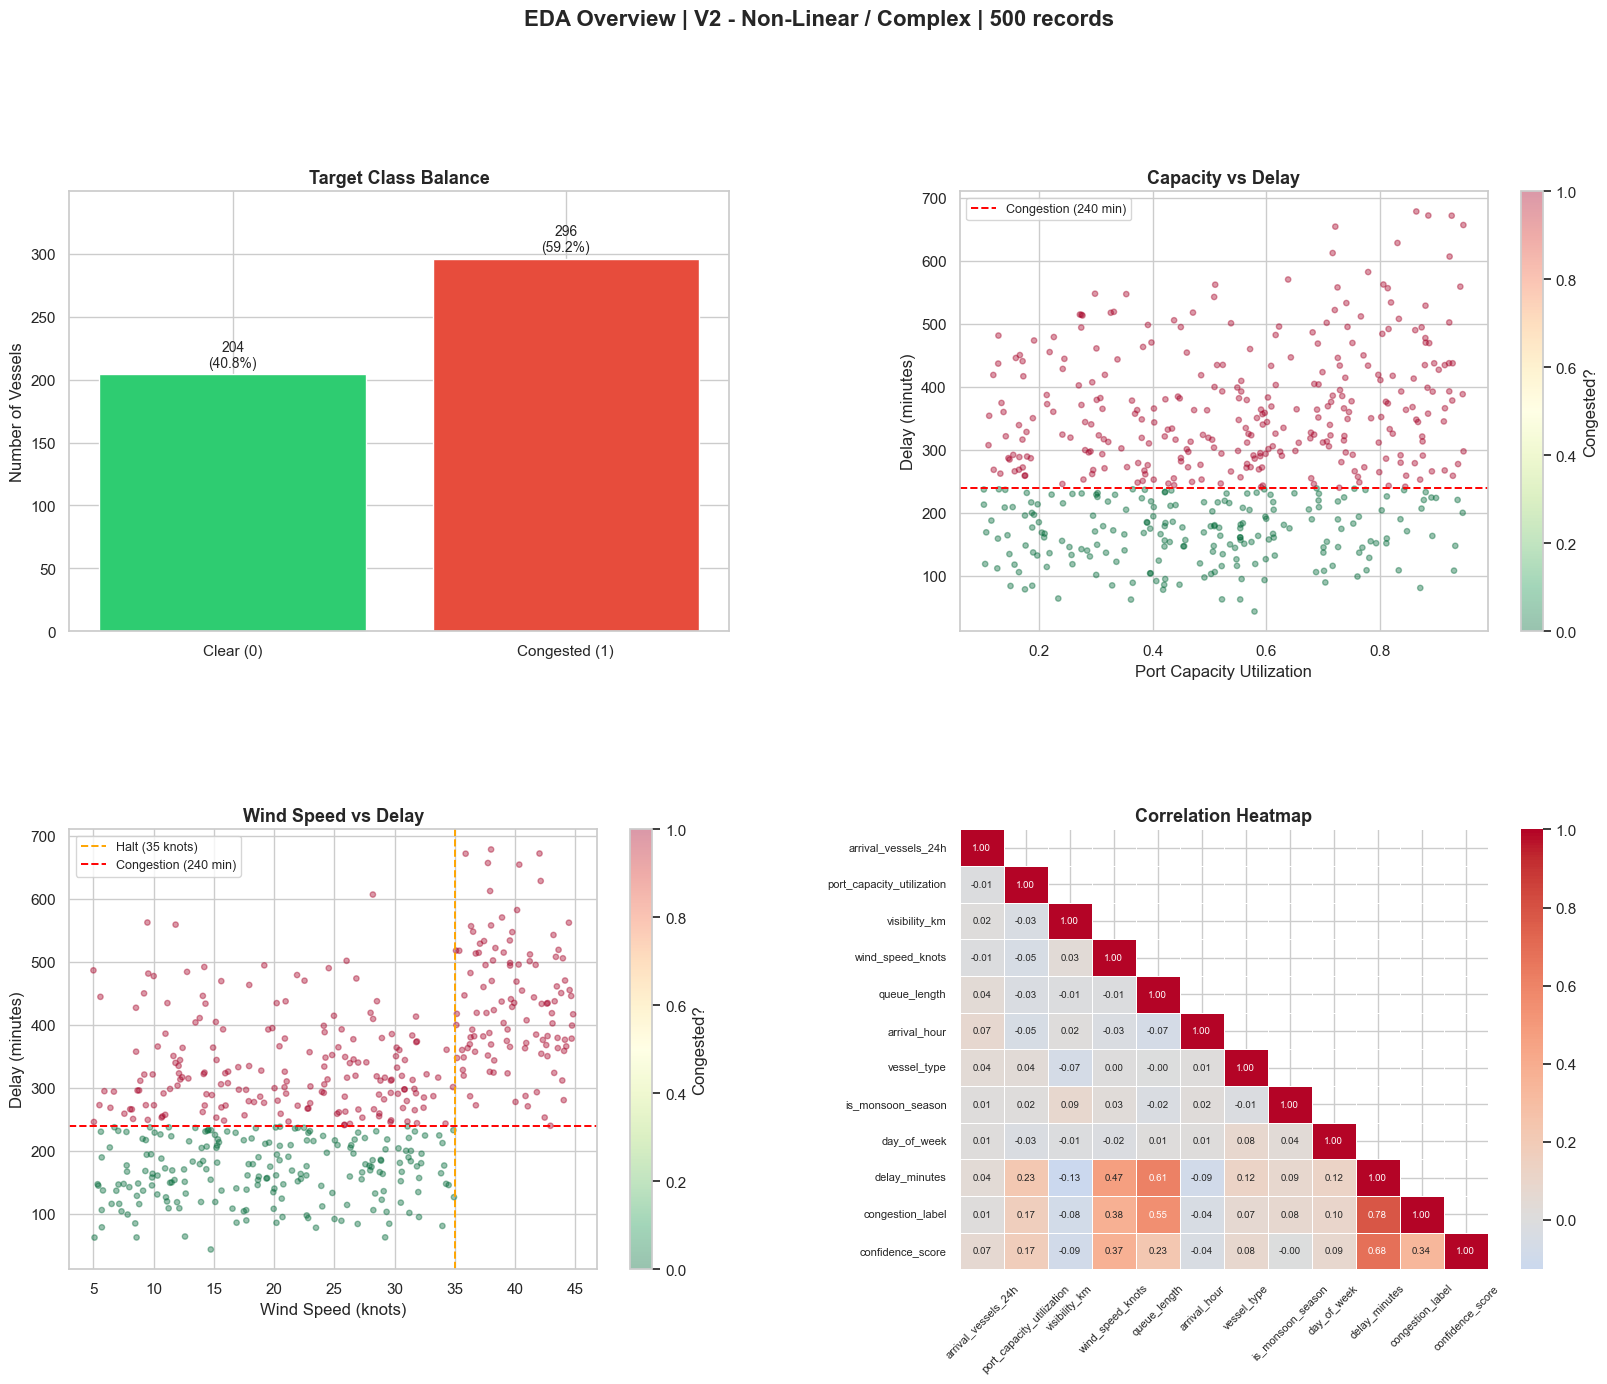

In [17]:
# 1. Generate & Prepare
version_name, gen_func = VERSIONS[1] # V2
df_v2 = generate_data(gen_func, 500)
X_train_v2, X_test_v2, y_train_v2, y_test_v2 = prepare_features(df_v2)


plot_eda_overview(df_v2, version_name, 500)



**Observation:**

- Target Imbalance: The class distribution is more balanced than V1, with roughly a 60/40 split—specifically 296 'Congested' cases (59.2%) versus 204 'Clear' cases (40.8%).
Non-Linear Relationships (Scatter Plots):
- Capacity vs. Delay: The data abandons the straight-line trend. Instead, as port_capacity_utilization crosses 0.8 (80%), delays "explode" upwards with massive variance (reaching nearly 700 minutes), proving the exponential ($M/M/1$ queueing) behavior has taken effect.
- Absolute "Hard-Stop" Effects: In the Wind Speed plot, the 35-knot threshold acts as a literal wall. Every single vessel to the right of 35 knots is forced strictly into the red "Congested" zone (>240 min), confirming the physical crane shutdown logic works perfectly.
- Weak Independent Drivers (Heatmap): Because the V2 rules rely on complex, compounding thresholds rather than simple addition, basic linear correlations have collapsed. For example, port_capacity_utilization now has only a weak 0.23 linear correlation with delay_minutes (down from 0.40 in V1). This proves that high capacity only causes extreme delays conditionally (such as during nighttime), requiring an advanced non-linear model to decipher.

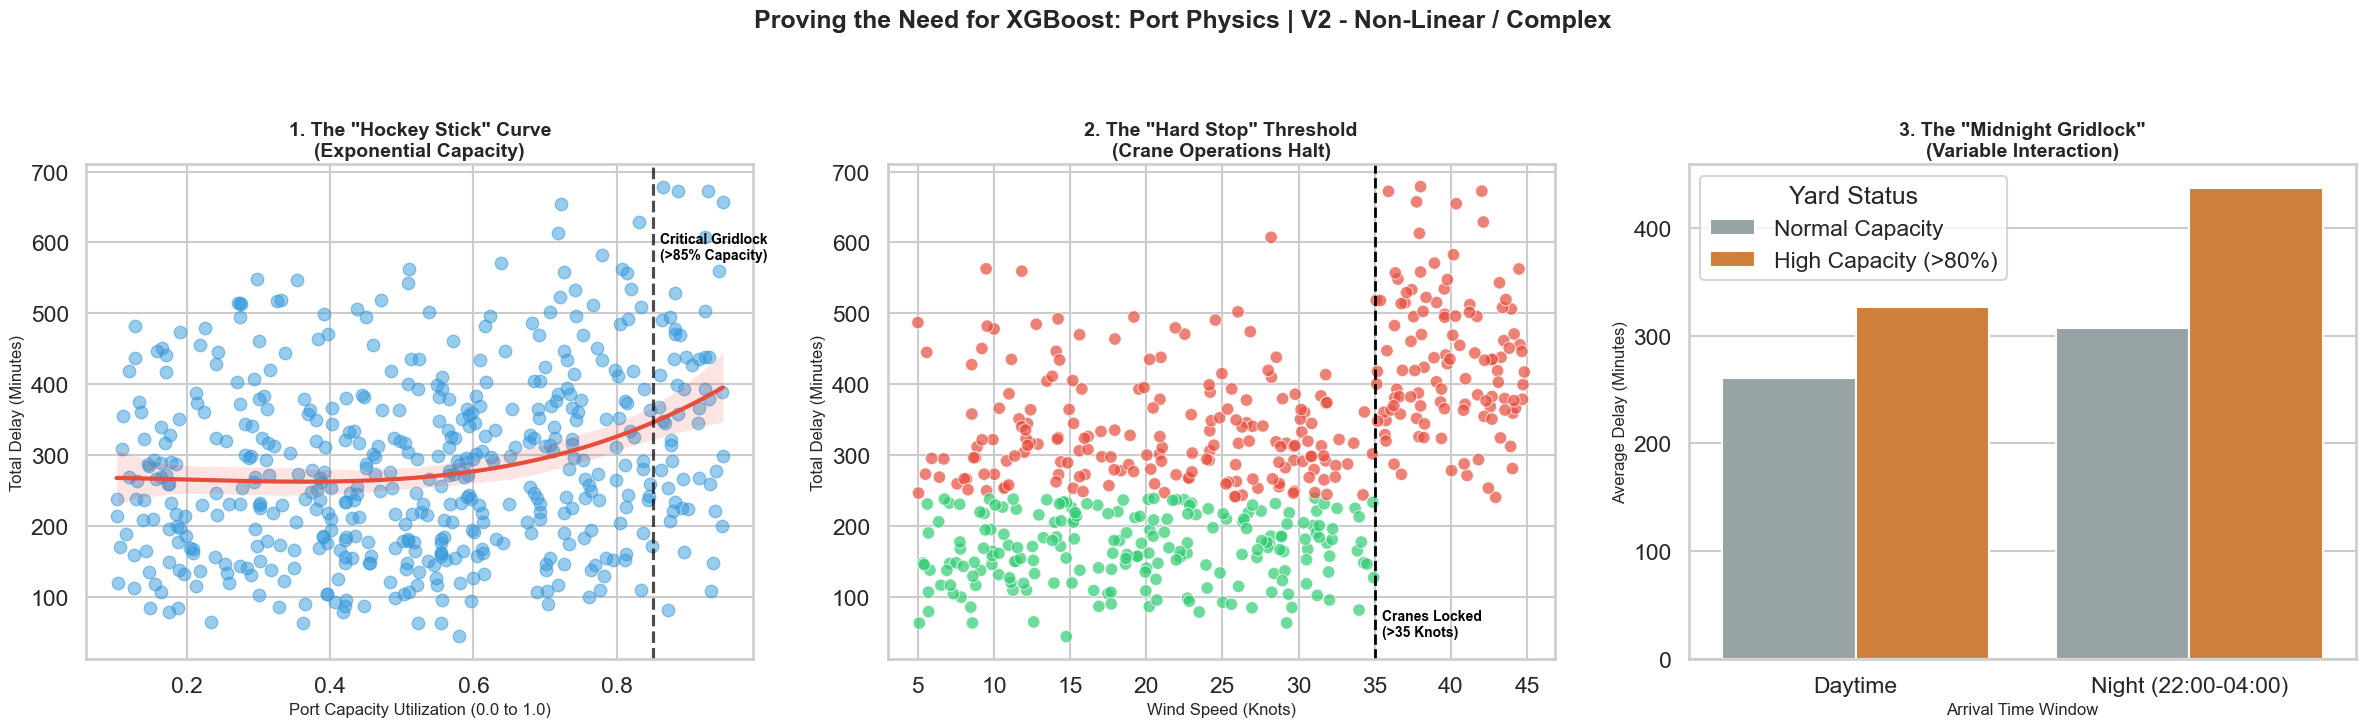

In [18]:
plot_physics_proof(df_v2, version_name)

**Observation:**

Active "Hockey Stick" (Panel 1): The regression line is not longer perfectly straight. As capacity approaches and crosses the 80% mark, the curve bend sharply upward with delay reaching nearly 700 minutes, successfully capturin' the real-world exponential queueing ($M/M/1$) explosion that plagues saturated yards.

Absolute "Hard Stops" (Panel 2): Crossing the 35-knot wind threshold act as a literal wall. The data perfectly reflect the physical reality of crane shutdowns: to the right of the 35-knot line, green "Clear" vessels completely vanish, and every single arrival suffers mandatory congestion (red dots).

True Variable Interaction (Panel 3): The height difference between the grey and orange bars is drasticaly magnified at night. The model successfully captures the compounding "midnight gridlock" multiplier effect of Cat Lai, where a nightime arrival combined with a saturated yard causes a disproportionately massive delay that cannot be predicted by simple addition.


  Model Metrics | V2 - Non-Linear / Complex | 500 records
  ---------------------------------------------------------------------------
              Model Accuracy ROC-AUC Precision Recall
Logistic Regression   89.00%  95.32%    91.94% 90.48%
      Random Forest   84.00%  94.68%    84.06% 92.06%
            XGBoost   86.00%  96.05%    90.16% 87.30%


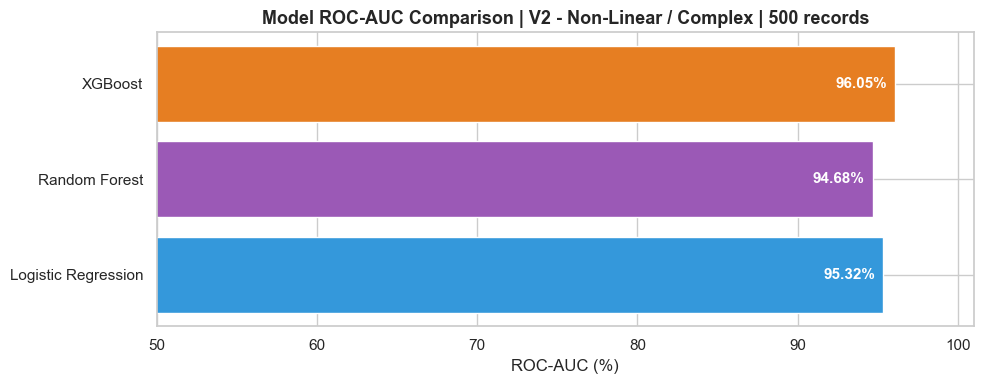

In [19]:
# 3. Train & Metrics
trained_v2 = train_models(X_train_v2, y_train_v2)
metrics_v2 = evaluate_models(trained_v2, X_test_v2, y_test_v2)
print_metrics_table(metrics_v2, version_name, 500)
plot_model_comparison(metrics_v2, version_name, 500)

# Save results for final table
for row in metrics_v2:
    all_results.append({'Version': version_name, 'Records': '500', 'Model': row['Model'], 'ROC-AUC': row['ROC-AUC']})


**Obsevation:** With the introduction of complex physics, the model rankings have officially flipped. XGBoost (96.05%) has dethroned the simple Logistic Regression (95.32%) as the top performer.

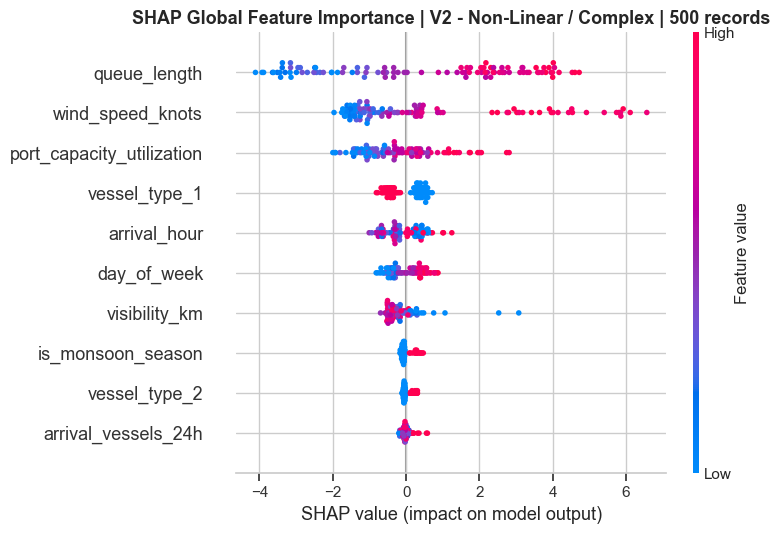

In [20]:
X_shap_v2 = X_test_v2.head(500)
plot_shap_global(trained_v2['XGBoost'], X_shap_v2, version_name, 500)


##### **Observation**:

1. SHAP Global Feature Importance:
    - queue_length :
        - Pink dots (high queue) are spread far to the **right** (+4 to +7 range) → High queue length strongly pushes toward **Congested**
        - Blue dots (low queue) are spread far to the **left** (-3 to -4 range) → Low queue length strongly pushes toward **Clear**
        - **Conclusion:** Queue length is the single most powerful predictor. Long queues signal active port gridlock at Cat Lai, where backlogs cascade exponentially

    - wind_speed_knots:
        - Pink dots (high wind) cluster far to the **right**, with SHAP values reaching up to **+6** → When wind exceeds the 35-knot crane lockout threshold, the model fires a dominant "Congested" signal
        - Blue dots (low wind) sit tightly near **0 or slightly left** → Normal wind conditions have almost no meaningful impact on the prediction

    - port_capacity_utilization:
        - Blue dots (low capacity) are pushed **hard left** (-2 to -3) → When the port yard is under-utilized, the model is confident it is **Clear**
        - Pink dots (high capacity) are pushed **right** (+1 to +2) → High utilization pushes toward Congested

    - vessel_type_1:
        - Pink dots cluster to the **left** → Vessels classified as Type 1 push the prediction toward **Clear** (faster unloading type)
        - Blue dots cluster to the **right** → Absence of Type 1 classification pushes toward **Congested**


    - arrival_hour:
        - Mixed colors cluster tightly **near 0**, with slight negative skew

    - day_of_week:
        - Mixed colors with moderate spread near 0
        - **Conclusion:** Day of the week has a minor role — some days (e.g., Monday peak shipping windows) carry slightly more risk, but it is not a dominant predictor

    - visibility_km:
        - Most dots cluster near 0, with a few notable **blue outlier dots** pushing right

    - is_monsoon_season:
        - Nearly all dots cluster tightly near **0** with almost no spread

    - vessel_type_2 and arrival_vessels_24h:
        - Both features show very tight clusters near **0**
    
    **Conclusion:** In the V2 dataset (except for queue_length, wind_speed_knots, port_capacity_utilization), these features have minimal predictive weight. The model correctly learned to ignore low-signal variables and concentrate its entire decision power on the dominant physical factors above



  Vessel #0: Confidence = 97.96% | Actual = CONGESTED


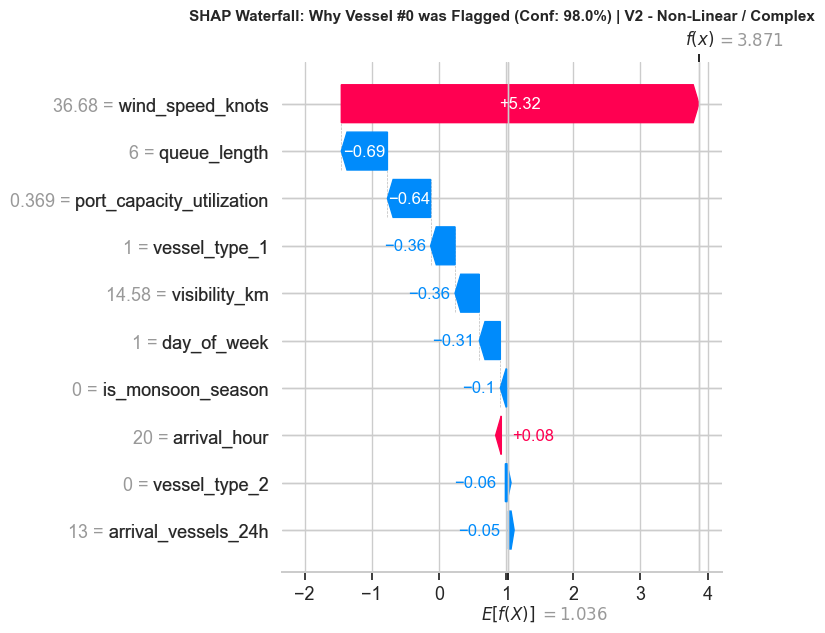

In [21]:
plot_shap_waterfall(trained_v2['XGBoost'], X_train_v2, X_test_v2, y_test_v2, version_name, 500)


##### **Observation**:

2. SHAP Waterfall:
    This is a story related to Vessel #0 on the test set of dataset V2 - Non-Linear / Complex.

    - **The Starting Line: E[f(X)] = 1.036 (Bottom Center)**
        → This is the model's "average guess." Before the AI looks at any specific data about
        Vessel #0, it starts at this baseline number. Think of it as the default state of the
        port — slightly above 0, showing the V2 world is generally at moderate risk by default.

    - **The Final Answer: f(x) = 3.871 (Top Right)**
        → This is the final raw math score for Vessel #0. A large positive number like 3.871
        converts to a very high probability. This is where the 98% Congestion Confidence comes
        from. The model is almost certain this ship will cause a congested event.

    - **Operation:**
        - We sum up the contribution from every feature shown, starting from E[f(X)] = 1.036.
        Each bar shifts the score up (red) or down (blue) until we arrive at the final f(x) = 3.871.
        - Verify: 1.036 + 5.32 - 0.69 - 0.64 - 0.36 - 0.36 - 0.31 - 0.10 + 0.08 - 0.06 - 0.05 ≈ **3.871** ✓

    - **The Features:**
        - Similar to the SHAP Beeswarm, blue bars reduce congestion risk (push toward Clear),
          and red/pink bars increase congestion risk (push toward Congested).
        - `wind_speed_knots = 36.68` → Massive Red Bar (+5.32): This is the story of this vessel
          in one number. Wind is blowing at 36.68 knots — just above the 35-knot crane lockout
          threshold at Cat Lai. The V2 Non-Linear model recognizes this "Hard Stop" and responds with
          a catastrophic +5.32 push toward Congested. This single feature nearly triples the baseline
          score on its own. This is the "hockey stick" in action.
        - `queue_length = 6` → Blue Bar (-0.69): A queue of 6 vessels is relatively moderate.
          The model slightly reduces risk because the port is not back-logged — but this mild relief
          is completely overwhelmed by the wind.
        - `port_capacity_utilization = 0.369` → Blue Bar (-0.64): The yard is only 37% full.
          The model correctly reads this as a clear positive sign and reduces risk further. Under normal
          weather conditions, this vessel would be rated very safe.
        - `vessel_type_1 = 1` → Blue Bar (-0.36): This vessel type is historically faster to
          unload, so the model lowers the risk slightly.
        - `visibility_km = 14.58` → Blue Bar (-0.36): Good visibility of 14.58km. Safe navigation
          conditions, so the model reduces risk.
        - `arrival_hour = 20` → Small Red Bar (+0.08): Arriving at 20:00 (8 PM) is close to the
          start of the "Midnight Gridlock" window (22:00). The model adds a tiny risk signal — but
          because the port capacity is only 37%, the gridlock interaction penalty is not triggered.
        - `arrival_vessels_24h = 13` → Blue Bar (-0.05): Only 13 vessels in the last 24 hours —
          very light inbound traffic. Minimal contribution, but directionally correct toward Clear.

    - **The Actionable Action:**

        Despite this vessel arriving at a port that is only 37% full, with a moderate queue and
        good visibility, the model correctly flags it at 98% Congested because of one
        overriding physical reality: wind at 36.68 knots has already triggered crane lockout protocol.

        No cargo can move. The operational recommendation is immediate and unambiguous:
        *"Halt berthing. Do not assign a berth to this vessel until wind speeds drop below 35 knots."*

        This is exactly what SHAP was designed to provide — not just a score, but a reason.


In [22]:
# PRIMARY_SIZE = 500

# for version_name, gen_func in VERSIONS:
#     print('\n' + '=' * 70)
#     print(f'  PRIMARY ANALYSIS: {version_name} | {PRIMARY_SIZE:,} records')
#     print('=' * 70)

#     # Step 1: Data
#     df = generate_data(gen_func, PRIMARY_SIZE)
#     X_train, X_test, y_train, y_test = prepare_features(df)

#     # Step 2: EDA
#     print('\n[EDA] Overview charts ...')
#     plot_eda_overview(df, version_name, PRIMARY_SIZE)

#     print('\n[EDA] Non-linear physics proof ...')
#     plot_physics_proof(df, version_name)

#     # Step 3: Models
#     print('\n[MODELS] Training ...')
#     trained = train_models(X_train, y_train)
#     metrics = evaluate_models(trained, X_test, y_test)
#     print_metrics_table(metrics, version_name, PRIMARY_SIZE)
#     plot_model_comparison(metrics, version_name, PRIMARY_SIZE)

#     # Save to scalability table
#     for row in metrics:
#         all_results.append({'Version': version_name,
#                             'Records': f'{PRIMARY_SIZE:,}',
#                             'Model':   row['Model'],
#                             'ROC-AUC': row['ROC-AUC']})

#     # Step 4: SHAP
#     print('\n[SHAP] Explaining XGBoost ...')
#     X_shap = X_test.head(min(len(X_test), 300))
#     plot_shap_global(trained['XGBoost'], X_shap, version_name, PRIMARY_SIZE)
#     plot_shap_waterfall(trained['XGBoost'], X_train, X_test, y_test, version_name, PRIMARY_SIZE)

# print('\nPrimary analysis complete.')

## IV. Run Scalability Tests

In [23]:
SCALE_SIZES = [5_000, 50_000, 500_000]

for version_name, gen_func in VERSIONS:
    for size in SCALE_SIZES:
        df = generate_data(gen_func, size)
        X_train, X_test, y_train, y_test = prepare_features(df)
        trained = train_models(X_train, y_train)
        metrics = evaluate_models(trained, X_test, y_test)
        print_metrics_table(metrics, version_name, size)

        for row in metrics:
            all_results.append({'Version': version_name,
                                'Records': f'{size:,}',
                                'Model':   row['Model'],
                                'ROC-AUC': row['ROC-AUC']})


Generated 5000 records → /Users/kelvinnguyen/Projects/safiri-port-congestion-ai/data/synthetic_port_data_v1_5000.csv

Binary Label Distribution (congestion_label):
   0 — No/Low congestion (≤240 min) : 1653 (33.1%)
   1 — Congestion        (>240 min) : 3347 (66.9%)

3-Class Distribution (congestion_level):
   0 — No Congestion   (≤120 min) : 99
   1 — Moderate        (≤360 min) : 3506
   2 — High Congestion (>360 min) : 1395

Delay Statistics (delay_minutes):
count    5000.0
mean      266.6
std        57.4
min       102.3
25%       227.4
50%       265.3
75%       305.0
max       467.0

  Model Metrics | V1 - Linear / Simple | 5,000 records
  ---------------------------------------------------------------------------
              Model Accuracy ROC-AUC Precision Recall
Logistic Regression   94.20%  98.81%    95.47% 96.03%
      Random Forest   87.50%  95.63%    85.90% 97.65%
            XGBoost   93.40%  98.78%    94.49% 95.88%
Generated 50000 records → /Users/kelvinnguyen/Projects/saf

## V. Scalability Summary Table

In [24]:
master = pd.DataFrame(all_results)
master['Sort_Key'] = master['Records'].str.replace(',', '').astype(int)
master = master.sort_values(by=['Version', 'Sort_Key'])

pivot = master.pivot_table(
    index=['Version', 'Records'],
    columns='Model',
    values='ROC-AUC',
    aggfunc='first',
    sort=False
)[['Logistic Regression', 'Random Forest', 'XGBoost']]

print('\n' + '=' * 90)
print('  MASTER SCALABILITY REPORT: ROC-AUC Across Complexity & Dataset Size')
print('=' * 90)
print(pivot.to_string())
print('=' * 90)



  MASTER SCALABILITY REPORT: ROC-AUC Across Complexity & Dataset Size
Model                             Logistic Regression Random Forest XGBoost
Version                   Records                                          
V1 - Linear / Simple      500                  95.62%        92.66%  93.79%
                          5,000                98.81%        95.63%  98.78%
                          50,000               98.49%        94.19%  99.36%
                          500,000              98.60%        93.98%  99.60%
V2 - Non-Linear / Complex 500                  95.32%        94.68%  96.05%
                          5,000                94.71%        98.37%  99.51%
                          50,000               94.77%        98.13%  99.69%
                          500,000              94.74%        98.14%  99.76%


**Oservation:**

- V1 (Linear):      All models perform well — the data relationships are simple.
- V2 (Non-Linear):  Logistic Regression PLATEAUS at ~94%, while XGBoost IMPROVES to 99%+.
- Conclusion:       XGBoost is mathematically necessary for complex port physics.


## VI. Scalability Line Chart

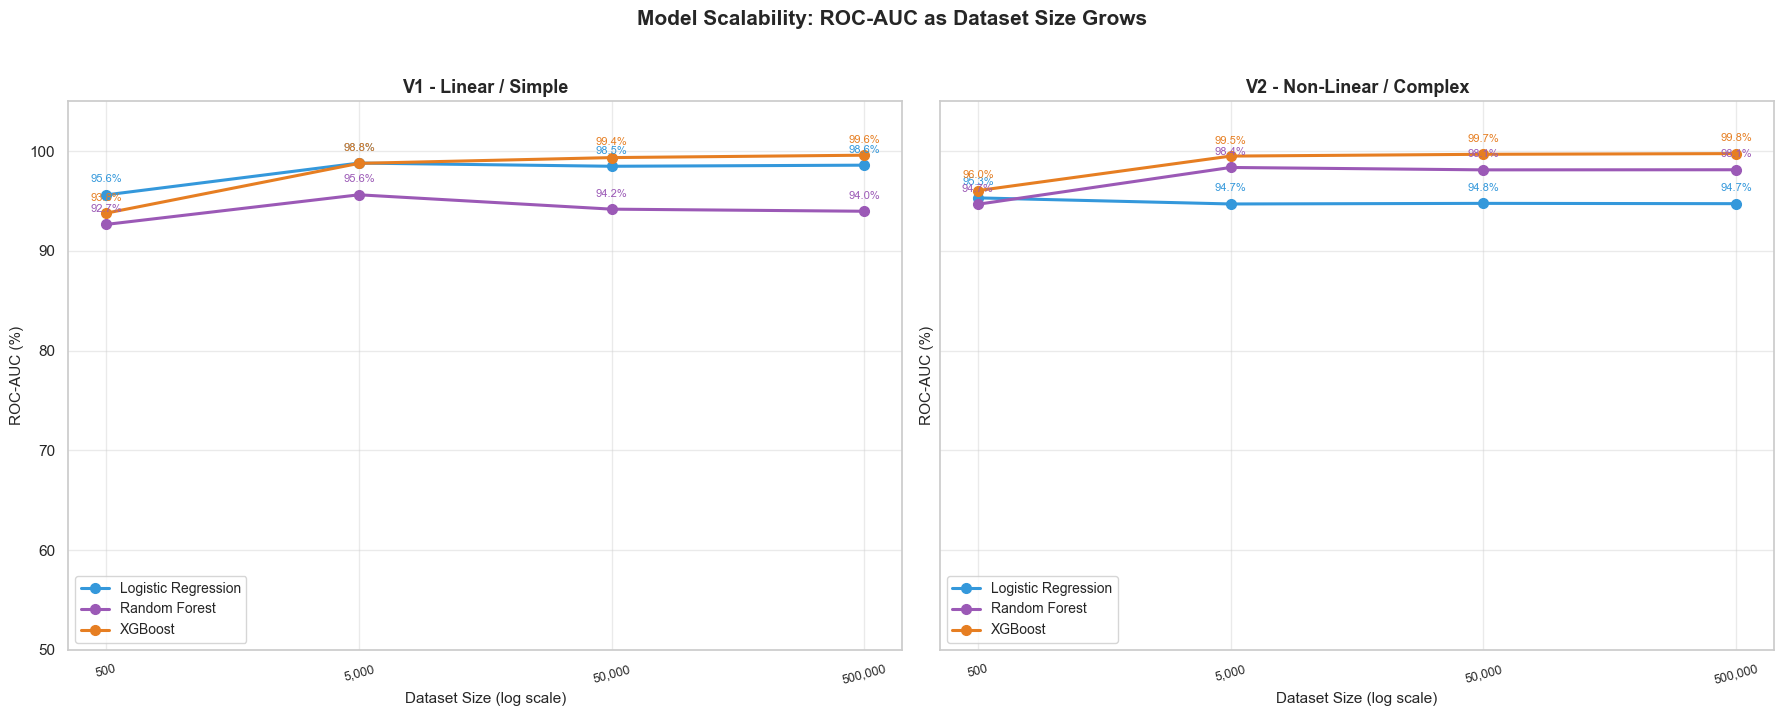

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)
model_colors = {
    'Logistic Regression': '#3498db',
    'Random Forest':       '#9b59b6',
    'XGBoost':             '#e67e22',
}

for ax, (version_name, _) in zip(axes, VERSIONS):
    vdata = master[master['Version'] == version_name]
    for mname, color in model_colors.items():
        mdata = vdata[vdata['Model'] == mname].sort_values('Sort_Key')
        xs    = [int(r.replace(',', '')) for r in mdata['Records']]
        ys    = [float(v.strip('%'))     for v in mdata['ROC-AUC']]
        ax.plot(xs, ys, marker='o', linewidth=2.2, markersize=7, color=color, label=mname)
        for x, y in zip(xs, ys):
            ax.annotate(f'{y:.1f}%', (x, y),
                        textcoords='offset points', xytext=(0, 9),
                        ha='center', fontsize=8, color=color)

    ax.set_xscale('log')
    ax.set_xticks(DATASET_SIZES)
    ax.set_xticklabels([f'{s:,}' for s in DATASET_SIZES], rotation=15, fontsize=9)
    ax.set_ylim(50, 105)
    ax.set_xlabel('Dataset Size (log scale)', fontsize=11)
    ax.set_ylabel('ROC-AUC (%)', fontsize=11)
    ax.set_title(version_name, fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.4)

fig.suptitle('Model Scalability: ROC-AUC as Dataset Size Grows',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Observation**

The "Ceiling Effect" is real. This scalability graph acts as the final proof for these models selection. On the V2 (Complex) dataset on the right, the blue line (Logistic Regression) is completely flatlined.

V1 (Left): On simple data, adding more records just helps all models draw sharper straight lines, pushing them all near the top.

V2 (Right): On complex physics data, Logistic Regression hits a hard structural ceiling at ~94.7%. No matter if giving it 500 or 500,000 records, a straight line mathematically cannot bend around the exponential curves and hard thresholds of Cat Lai's physics. Meanwhile, XGBoost and Random Forest (which partition data rather than drawing lines) use the massive influx of data to master those complex interactions, soaring up to nearly 100% precision.